In [2]:
#Import Libraries

import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# load dataset

housing = fetch_california_housing(as_frame=True)

df = housing.frame

In [4]:
# display 5 rows 

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [5]:
# dataset information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [6]:
# statistical summary 

print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [7]:
# check missing values

print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [8]:
# features and target

X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

In [9]:
# split dataset

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [10]:
# linear regression

linear = LinearRegression()

linear.fit(X_train, y_train)

linear_pred = linear.predict(X_test)

In [11]:
# evaluate linear regression

linear_r2 = r2_score(y_test, linear_pred)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

print("Linear Regression")

print("R2 Score =", linear_r2)

print("RMSE =", linear_rmse)

Linear Regression
R2 Score = 0.575787706032451
RMSE = 0.7455813830127763


In [14]:
# polynomial regression (degree 2)

poly2 = make_pipeline(

    PolynomialFeatures(degree=2),

    LinearRegression()

)

poly2.fit(X_train, y_train)

poly2_pred = poly2.predict(X_test)

In [15]:
# evaluation

poly2_r2 = r2_score(y_test, poly2_pred)

poly2_rmse = np.sqrt(mean_squared_error(y_test, poly2_pred))

print("Polynomial Degree 2")

print("R2 =", poly2_r2)

print("RMSE =", poly2_rmse)

Polynomial Degree 2
R2 = 0.6456819949199755
RMSE = 0.6813967236561009


In [16]:
# Polynomial Regression (Degree = 3)

poly3 = make_pipeline(

    PolynomialFeatures(degree=3),

    LinearRegression()

)

poly3.fit(X_train, y_train)

poly3_pred = poly3.predict(X_test)

In [17]:
# evaluation

poly3_r2 = r2_score(y_test, poly3_pred)

poly3_rmse = np.sqrt(mean_squared_error(y_test, poly3_pred))

print("Polynomial Degree 3")

print("R2 =", poly3_r2)

print("RMSE =", poly3_rmse)

Polynomial Degree 3
R2 = -2.5113629529893498
RMSE = 2.1450691223034566


In [18]:
# ridge regression

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [19]:
# evaluation

ridge_r2 = r2_score(y_test, ridge_pred)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print("Ridge Regression")

print("R2 =", ridge_r2)

print("RMSE =", ridge_rmse)

Ridge Regression
R2 = 0.5758549611440127
RMSE = 0.7455222779992702


In [20]:
# lasso regression

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

In [21]:
# evaluation

lasso_r2 = r2_score(y_test, lasso_pred)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print("Lasso Regression")

print("R2 =", lasso_r2)

print("RMSE =", lasso_rmse)

Lasso Regression
R2 = 0.5318167610318159
RMSE = 0.7832697618354822


In [22]:
# compare all models

comparison = pd.DataFrame({

    "Model": [

        "Linear Regression",

        "Polynomial Degree 2",

        "Polynomial Degree 3",

        "Ridge Regression",

        "Lasso Regression"

    ],

    "R2 Score": [

        linear_r2,

        poly2_r2,

        poly3_r2,

        ridge_r2,

        lasso_r2

    ],

    "RMSE": [

        linear_rmse,

        poly2_rmse,

        poly3_rmse,

        ridge_rmse,

        lasso_rmse

    ]

})

print(comparison)

                 Model  R2 Score      RMSE
0    Linear Regression  0.575788  0.745581
1  Polynomial Degree 2  0.645682  0.681397
2  Polynomial Degree 3 -2.511363  2.145069
3     Ridge Regression  0.575855  0.745522
4     Lasso Regression  0.531817  0.783270


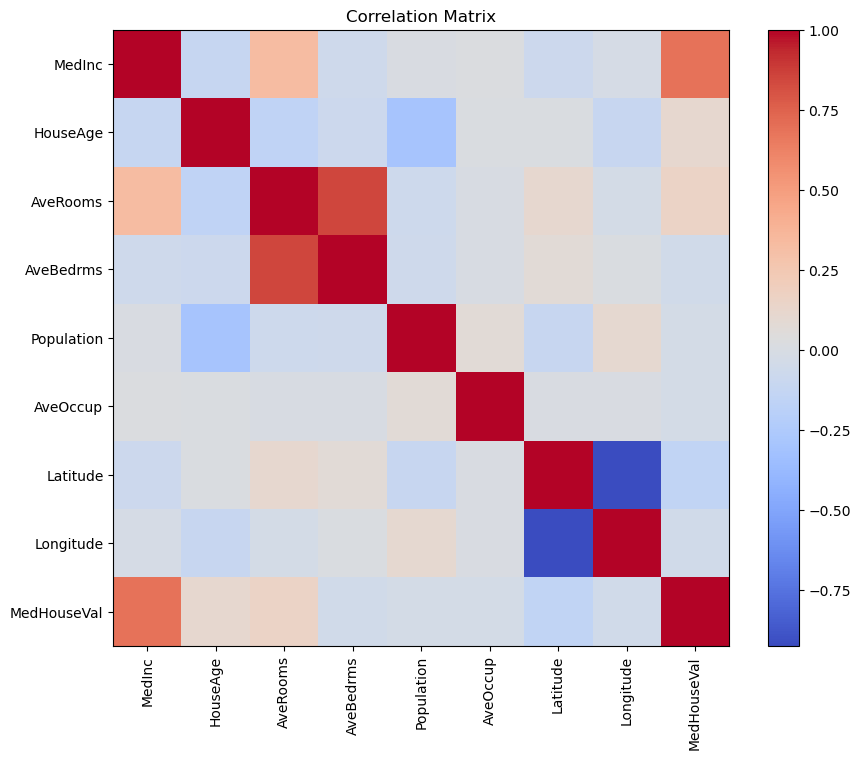

In [25]:
# correlation heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(df.corr(), cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Matrix")

plt.show()